# 📊 05 — Visualization & Dashboard
## FIFA World Cup 2026 Prediction Project

Notebook ini membuat visualisasi komprehensif dari hasil prediksi:
- Championship probability chart
- Group-by-group analysis
- Team strength radar charts
- Tournament progression probabilities
- Elo rating comparisons

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')
from src.features import normalize_team_names_in_df

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100

OUTPUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')

In [2]:
# Load results
sim_results = pd.read_csv(OUTPUT_DIR / 'predictions' / 'wc2026_simulation_results.csv')
team_profiles = pd.read_csv(OUTPUT_DIR / 'predictions' / 'wc2026_team_profiles.csv')
elo_ratings = pd.read_csv(OUTPUT_DIR / 'predictions' / 'elo_ratings.csv')
wc2026_groups = pd.read_csv(DATA_DIR / '2026_world_cup_groups.csv')
wc2026_groups = normalize_team_names_in_df(wc2026_groups, ['Team'])

# Merge group info
sim_results = sim_results.merge(
    wc2026_groups[['Team', 'Group', 'FIFA Ranking']], on='Team', how='left'
)

print(f'Loaded {len(sim_results)} teams')

Loaded 48 teams


## 1. 🏆 Championship Probability — Top 20

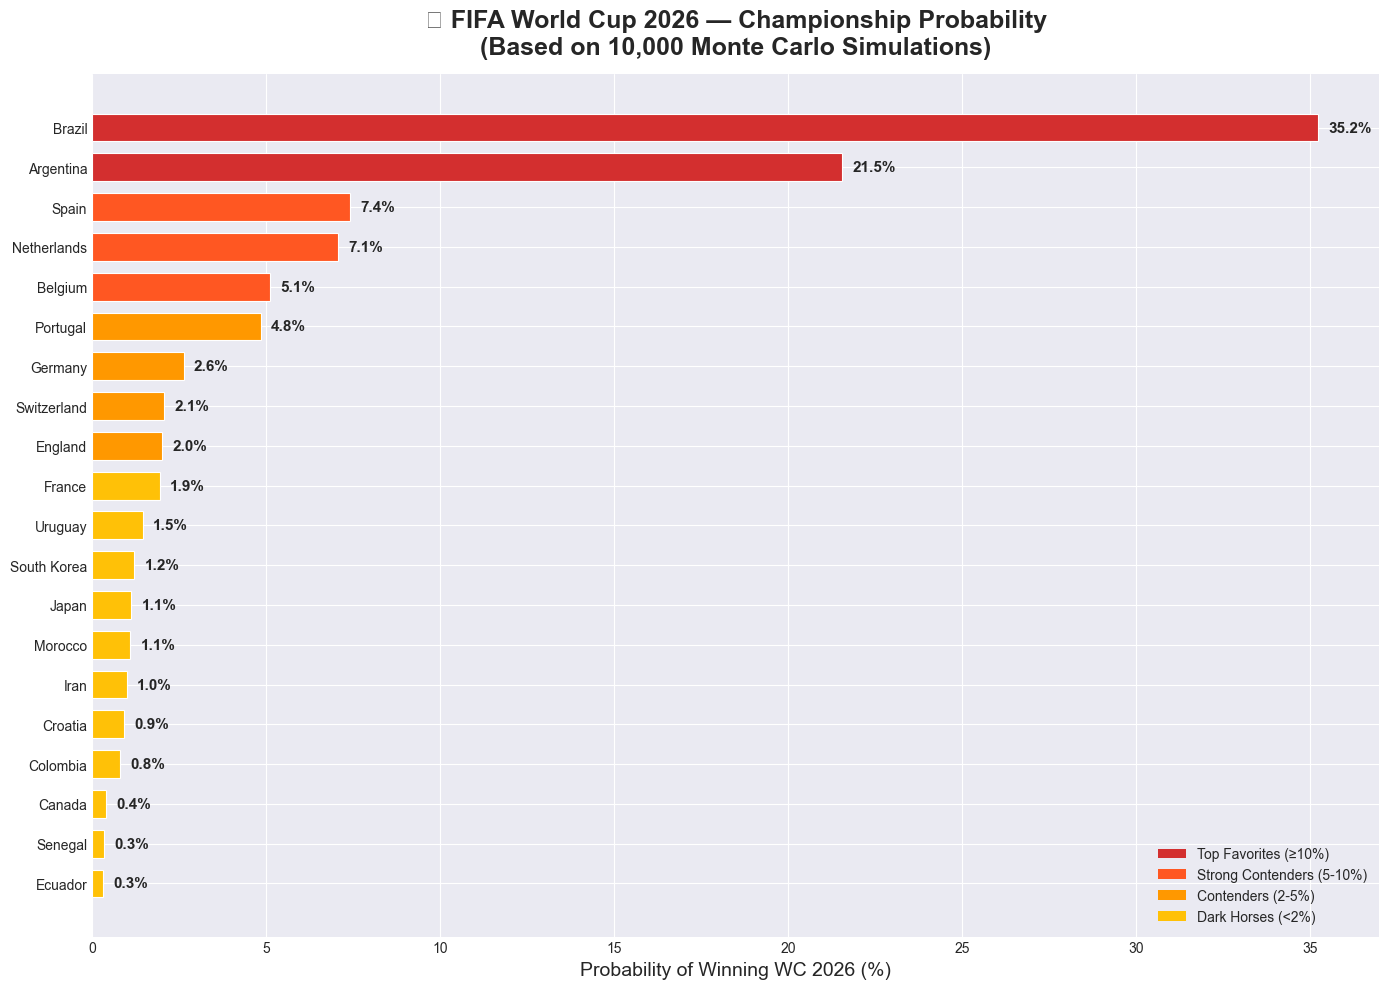

In [3]:
top20 = sim_results.head(20).copy()

fig, ax = plt.subplots(figsize=(14, 10))

# Color by probability tier
colors = []
for p in top20['p_champion']:
    if p >= 0.10:
        colors.append('#D32F2F')  # Top favorites (red)
    elif p >= 0.05:
        colors.append('#FF5722')  # Strong contenders (orange)
    elif p >= 0.02:
        colors.append('#FF9800')  # Contenders (amber)
    else:
        colors.append('#FFC107')  # Dark horses (yellow)

bars = ax.barh(top20['Team'].iloc[::-1], top20['p_champion'].iloc[::-1] * 100,
               color=colors[::-1], edgecolor='white', linewidth=0.8, height=0.7)

for bar, val, team in zip(bars, top20['p_champion'].iloc[::-1] * 100, top20['Team'].iloc[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#D32F2F', label='Top Favorites (≥10%)'),
    mpatches.Patch(facecolor='#FF5722', label='Strong Contenders (5-10%)'),
    mpatches.Patch(facecolor='#FF9800', label='Contenders (2-5%)'),
    mpatches.Patch(facecolor='#FFC107', label='Dark Horses (<2%)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.set_xlabel('Probability of Winning WC 2026 (%)', fontsize=14)
ax.set_title('🏆 FIFA World Cup 2026 — Championship Probability\n'
             '(Based on 10,000 Monte Carlo Simulations)',
             fontsize=18, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/figures/05_champion_prob_top20.png', dpi=200, bbox_inches='tight')
plt.show()

## 2. 📊 Tournament Stage Progression

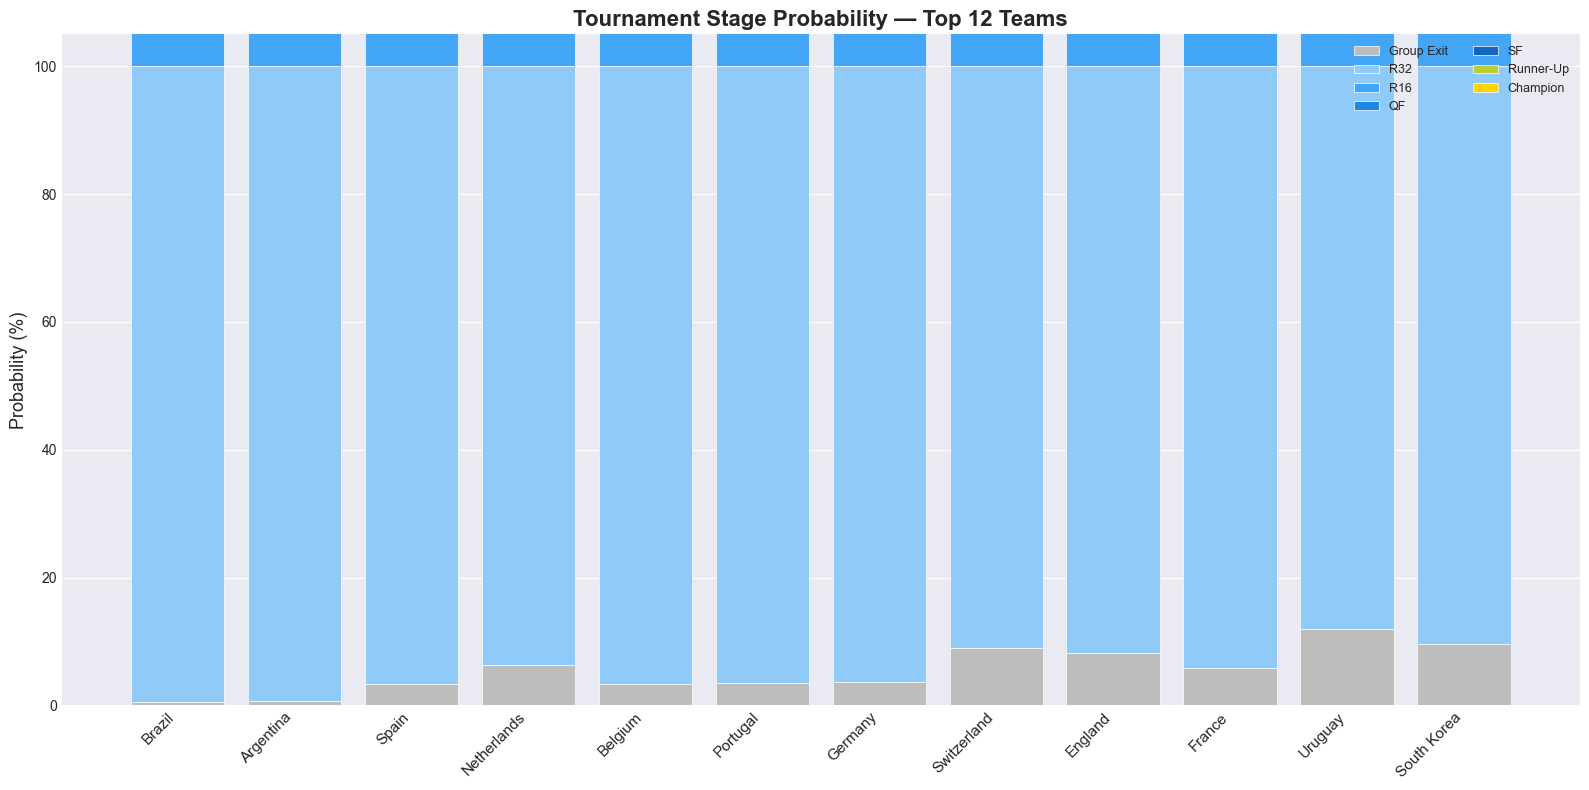

In [4]:
# Stacked bar chart: probability of reaching each stage
top12 = sim_results.head(12).copy()
stages = ['p_group_stage_exit', 'p_round_of_32', 'p_round_of_16', 
          'p_quarter_finals', 'p_semi_finals', 'p_runner_up', 'p_champion']
stage_labels = ['Group Exit', 'R32', 'R16', 'QF', 'SF', 'Runner-Up', 'Champion']
stage_colors = ['#BDBDBD', '#90CAF9', '#42A5F5', '#1E88E5', '#1565C0', '#C0CA33', '#FFD600']

fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(top12))
bottom = np.zeros(len(top12))

for stage, label, color in zip(stages, stage_labels, stage_colors):
    if stage in top12.columns:
        values = top12[stage].values * 100
        ax.bar(x, values, bottom=bottom, label=label, color=color, 
               edgecolor='white', linewidth=0.5)
        bottom += values

ax.set_xticks(x)
ax.set_xticklabels(top12['Team'], rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Probability (%)', fontsize=13)
ax.set_title('Tournament Stage Probability — Top 12 Teams', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('../outputs/figures/05_stage_progression.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. 🗺️ Group-by-Group Qualification Probability

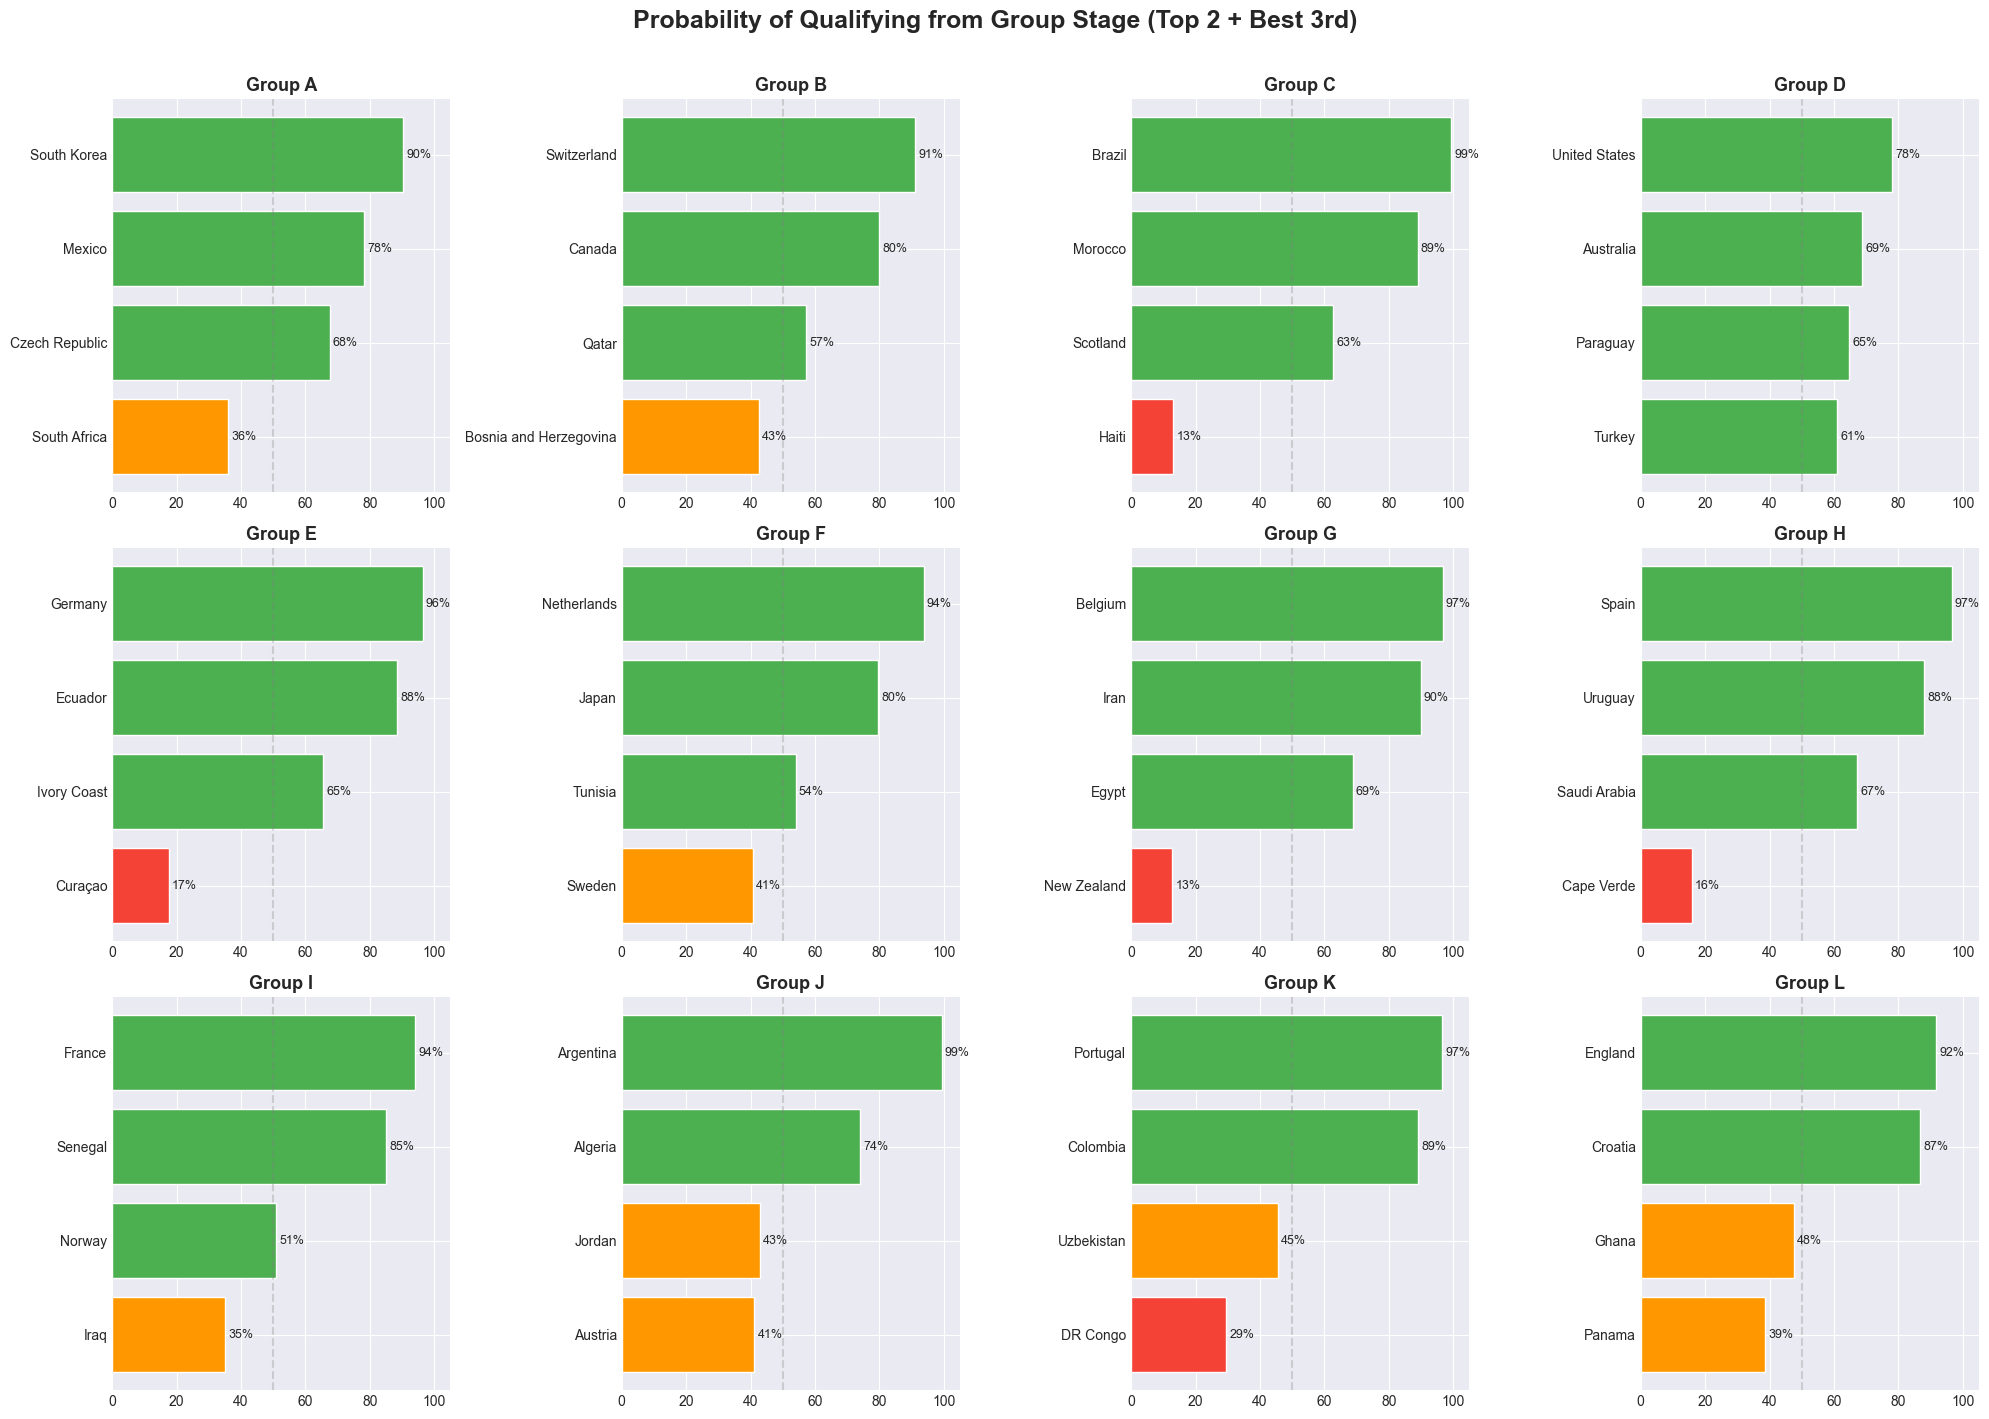

In [5]:
# Group stage qualification probability per group
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, group_name in enumerate(sorted(wc2026_groups['Group'].unique())):
    ax = axes[i]
    group_teams = wc2026_groups[wc2026_groups['Group'] == group_name]['Team'].tolist()
    group_data = sim_results[sim_results['Team'].isin(group_teams)].sort_values('p_round_of_32', ascending=True)
    
    if len(group_data) > 0:
        colors_g = ['#4CAF50' if p > 0.5 else '#FF9800' if p > 0.3 else '#F44336' 
                     for p in group_data['p_round_of_32']]
        
        bars = ax.barh(group_data['Team'], group_data['p_round_of_32'] * 100, 
                       color=colors_g, edgecolor='white')
        
        for bar, val in zip(bars, group_data['p_round_of_32'] * 100):
            ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}%', va='center', fontsize=9)
    
    ax.set_title(f'Group {group_name}', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.axvline(x=50, color='gray', linestyle='--', alpha=0.3)

plt.suptitle('Probability of Qualifying from Group Stage (Top 2 + Best 3rd)',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/05_group_qualification.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. 🎯 Team Strength Radar Chart

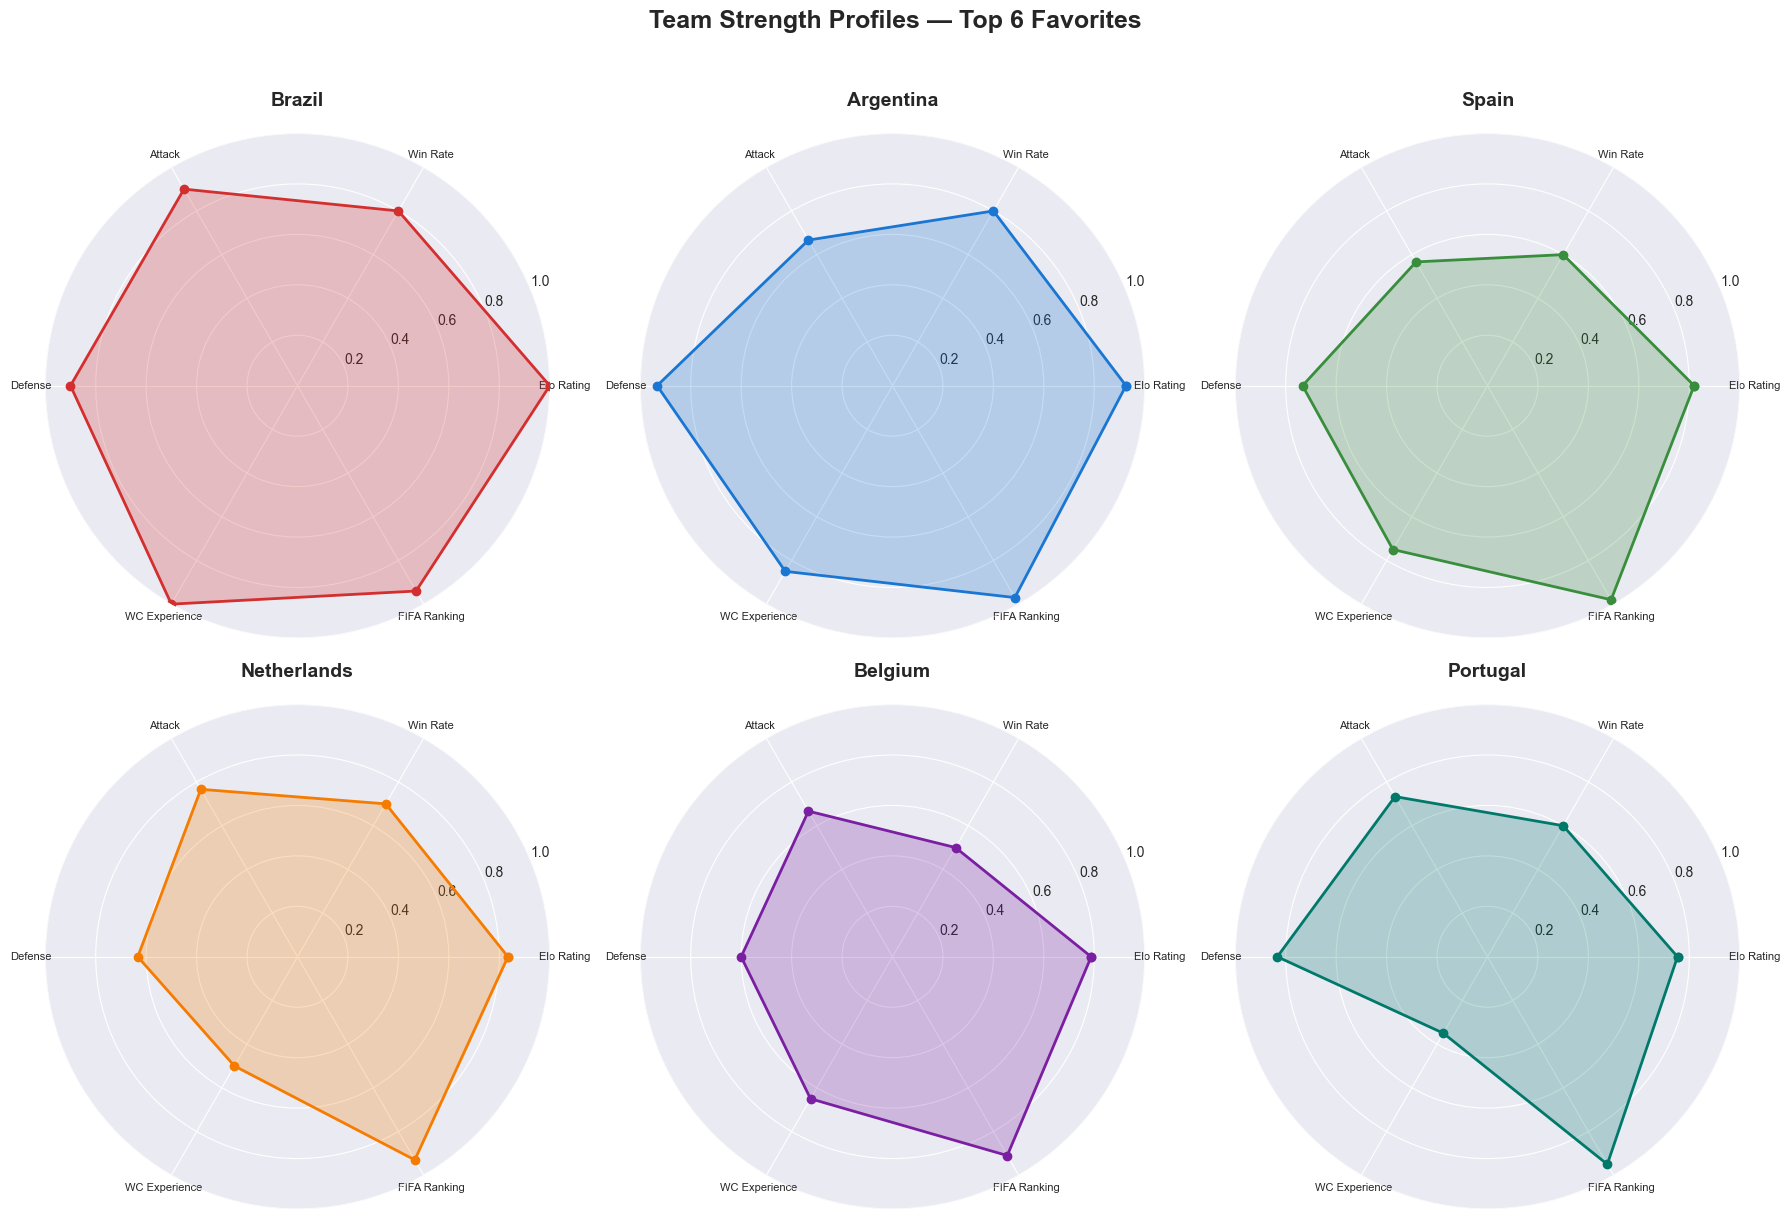

In [6]:
# Radar chart for top 6 teams
if team_profiles is not None and len(team_profiles) > 0:
    top6_teams = sim_results.head(6)['Team'].tolist()
    
    categories = ['Elo Rating', 'Win Rate', 'Attack', 'Defense', 'WC Experience', 'FIFA Ranking']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(projection='polar'))
    axes = axes.flatten()
    
    # Normalize features to 0-1 scale for radar
    all_elos = [elo_ratings[elo_ratings['Team'] == t]['Elo'].values[0] 
                if t in elo_ratings['Team'].values else 1500 for t in top6_teams]
    elo_max = max(all_elos) if all_elos else 2000
    elo_min = min(1300, min(all_elos) if all_elos else 1300)
    
    colors_radar = ['#D32F2F', '#1976D2', '#388E3C', '#F57C00', '#7B1FA2', '#00796B']
    
    for i, team in enumerate(top6_teams):
        ax = axes[i]
        
        tp = team_profiles[team_profiles['Team'] == team]
        if len(tp) == 0:
            continue
        tp = tp.iloc[0]
        
        # Normalize each metric to 0-1
        values = [
            min((tp.get('Elo', 1500) - elo_min) / (elo_max - elo_min), 1.0),
            min(tp.get('Win_Rate_Last10', 0.5), 1.0),
            min(tp.get('Avg_Goals_Scored', 1.0) / 3.0, 1.0),
            max(1.0 - tp.get('Avg_Goals_Conceded', 1.0) / 3.0, 0.0),
            min(tp.get('WC_Appearances', 0) / 20.0, 1.0),
            max(1.0 - tp.get('FIFA_Ranking', 50) / 100.0, 0.0),
        ]
        
        # Plot radar
        angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
        values_plot = values + [values[0]]  # Close the polygon
        angles_plot = angles + [angles[0]]
        
        ax.plot(angles_plot, values_plot, 'o-', linewidth=2, color=colors_radar[i])
        ax.fill(angles_plot, values_plot, alpha=0.25, color=colors_radar[i])
        ax.set_xticks(angles)
        ax.set_xticklabels(categories, fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_title(team, fontsize=14, fontweight='bold', pad=20)
    
    plt.suptitle('Team Strength Profiles — Top 6 Favorites', 
                 fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/figures/05_radar_charts.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('Team profiles not available. Run notebook 02 first.')

## 5. 📈 Elo vs FIFA Ranking vs Champion Probability

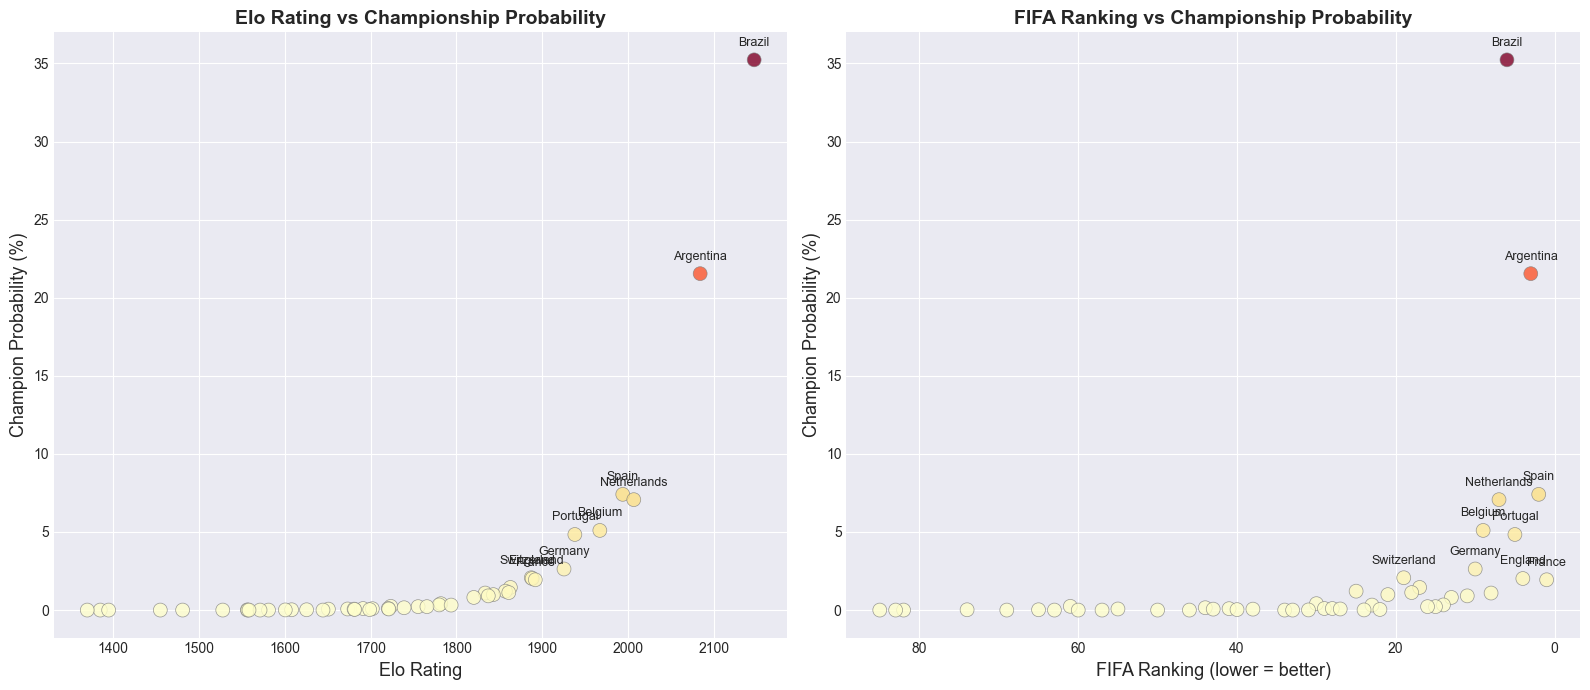

In [7]:
# Scatter plot: Elo vs Champion Probability
merged = sim_results.merge(elo_ratings, on='Team', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Elo vs Champion Prob
ax = axes[0]
scatter = ax.scatter(merged['Elo'], merged['p_champion'] * 100,
                     s=100, c=merged['p_champion'] * 100, cmap='YlOrRd',
                     edgecolors='gray', linewidth=0.5, alpha=0.8)

for _, r in merged.head(10).iterrows():
    ax.annotate(r['Team'], (r['Elo'], r['p_champion'] * 100),
                fontsize=9, ha='center', va='bottom',
                textcoords='offset points', xytext=(0, 8))

ax.set_xlabel('Elo Rating', fontsize=13)
ax.set_ylabel('Champion Probability (%)', fontsize=13)
ax.set_title('Elo Rating vs Championship Probability', fontsize=14, fontweight='bold')

# FIFA Ranking vs Champion Prob
ax = axes[1]
if 'FIFA Ranking' in merged.columns:
    scatter2 = ax.scatter(merged['FIFA Ranking'], merged['p_champion'] * 100,
                          s=100, c=merged['p_champion'] * 100, cmap='YlOrRd',
                          edgecolors='gray', linewidth=0.5, alpha=0.8)
    
    for _, r in merged.head(10).iterrows():
        ax.annotate(r['Team'], (r['FIFA Ranking'], r['p_champion'] * 100),
                    fontsize=9, ha='center', va='bottom',
                    textcoords='offset points', xytext=(0, 8))
    
    ax.invert_xaxis()

ax.set_xlabel('FIFA Ranking (lower = better)', fontsize=13)
ax.set_ylabel('Champion Probability (%)', fontsize=13)
ax.set_title('FIFA Ranking vs Championship Probability', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/05_elo_vs_champion.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. 📋 Final Summary Table

In [8]:
# Final summary
print('\n' + '='*80)
print('  🏆 FIFA WORLD CUP 2026 — PREDICTION SUMMARY')
print('='*80)

print('\n📊 Top 10 Most Likely Champions:')
for i, (_, r) in enumerate(sim_results.head(10).iterrows()):
    bar_len = int(r['p_champion'] * 200)
    bar = '█' * bar_len
    print(f'  {i+1:2d}. {r["Team"]:20s} {r["p_champion"]*100:5.1f}% {bar}')

print(f'\n🔮 Predicted Winner: {sim_results.iloc[0]["Team"]} '
      f'({sim_results.iloc[0]["p_champion"]*100:.1f}% probability)')

print(f'\n📈 Most Likely Finalists:')
finalists = sim_results.sort_values('p_runner_up', ascending=False).head(5)
for _, r in finalists.iterrows():
    print(f'  {r["Team"]:20s} Final: {(r["p_champion"]+r["p_runner_up"])*100:.1f}%')

print('\n✅ All visualizations saved to outputs/figures/')
print('   Next: 06_model_evaluation.ipynb for backtesting')


  🏆 FIFA WORLD CUP 2026 — PREDICTION SUMMARY

📊 Top 10 Most Likely Champions:
   1. Brazil                35.2% ██████████████████████████████████████████████████████████████████████
   2. Argentina             21.5% ███████████████████████████████████████████
   3. Spain                  7.4% ██████████████
   4. Netherlands            7.1% ██████████████
   5. Belgium                5.1% ██████████
   6. Portugal               4.8% █████████
   7. Germany                2.6% █████
   8. Switzerland            2.1% ████
   9. England                2.0% ████
  10. France                 1.9% ███

🔮 Predicted Winner: Brazil (35.2% probability)

📈 Most Likely Finalists:
  Argentina            Final: 37.8%
  Brazil               Final: 48.2%
  Portugal             Final: 13.1%
  Spain                Final: 13.6%
  Netherlands          Final: 13.3%

✅ All visualizations saved to outputs/figures/
   Next: 06_model_evaluation.ipynb for backtesting
